In [27]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import  BaseModel,Field

import operator
load_dotenv()

True

In [28]:
class EssayEvalState(TypedDict):
    essay:str
    clarityFeedback:str
    technicalFeedback:str
    languageFeedback:str
    induvScores:Annotated[list[int],operator.add]
    avgScore:float
    summary:str

In [29]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


In [30]:
class LLmOutput(BaseModel):
    feedback:str = Field(description="Feedback of the essay")
    score:int=Field(description="Score in integer out of 10")

In [31]:
llms = llm.with_structured_output(LLmOutput)

In [32]:
def clarityAnalyse(state:EssayEvalState):
    essay = state["essay"]
    prompt = f"Read the essay and give  feedback based on clarity only clarityanalysis and give score out of 10 in structure format as prescribed essay : \n {essay}"

    clarityFeedback =llms.invoke(prompt)
    state["clarityFeedback"]=clarityFeedback.feedback
    state["induvScores"] = clarityFeedback.score


def technicalAnalysis(state:EssayEvalState):
    essay = state["essay"]
    prompt = f"Read the essay and give  feedback based on technicality only technicalanalysis and give score out of 10 in structure format as prescribed essay : \n {essay}"

    technicalFeedback =llms.invoke(prompt)
    state["technicalFeedback"]=technicalFeedback.feedback
    state["induvScores"] = technicalFeedback.score



def languageAnalysis(state:EssayEvalState):
    essay = state["essay"]
    prompt = f"Read the essay and give  feedback based on language and grammer  only langguage analusis and give score out of 10 in structure format as prescribed essay : \n {essay}"

    languageFeedback =llms.invoke(prompt)
    state["languageFeedback"]=languageFeedback.feedback
    state["induvScores"] = languageFeedback.score

def summary(state:EssayEvalState):
    prompt=f"This is the data of users essayfeeback summarise it in one go :: \n data : {state} "
    summary = llm.invoke(prompt).content
    state["summary"]=summary
    return {"summary":summary}

In [33]:
graph = StateGraph(EssayEvalState)
graph.add_node("clarityAnalyse",clarityAnalyse)
graph.add_node("technicalAnalysis",technicalAnalysis)
graph.add_node("languageAnalysis",languageAnalysis)
graph.add_node("summary",summary)

graph.add_edge(START,"clarityAnalyse")
graph.add_edge(START,"technicalAnalysis")
graph.add_edge(START,"languageAnalysis")

graph.add_edge("clarityAnalyse","summary")
graph.add_edge("technicalAnalysis","summary")
graph.add_edge("languageAnalysis","summary")
graph.add_edge("summary",END)



In [34]:
workflow = graph.compile()

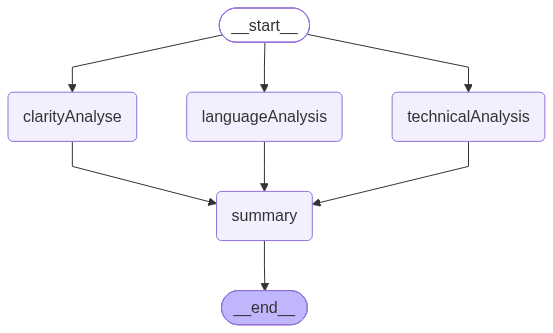

In [35]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [36]:
essay ="""Social anxiety is an intense, persistent fear of being judged, embarrassed, or negatively evaluated in social or performance situations.Understanding Social AnxietySocial anxiety goes far beyond simple shyness. It is a psychological condition—known clinically as Social Anxiety Disorder (SAD)—that affects millions of people globally.The Core Fear: The central mechanism is a deep-seated dread of scrutiny. Individuals feel as though all eyes are on them, magnifying their perceived flaws.Physical Manifestations: The body reacts with a hyperactive fight-or-flight response, leading to a rapid heart rate, sweating, trembling, and blushing.Behavioral Cycles: Sufferers often avoid triggering scenarios, such as public speaking, eating in public, or basic daily interactions. This avoidance reinforces the fear, deepening social isolation.Impact and TreatmentLeft unmanaged, social anxiety impairs academic performance, career growth, and personal relationships. It can foster low self-esteem and lead to secondary issues like depression.Fortunately, effective treatments exist. Cognitive-behavioral therapy (CBT) helps individuals challenge distorted thought patterns and gradually face feared situations. Combined with self-help strategies or medication when necessary, therapy allows many people to reclaim their lives and build meaningful connections."""

In [37]:
results = workflow.invoke({"essay":essay})
print(results)

{'essay': 'Social anxiety is an intense, persistent fear of being judged, embarrassed, or negatively evaluated in social or performance situations.Understanding Social AnxietySocial anxiety goes far beyond simple shyness. It is a psychological condition—known clinically as Social Anxiety Disorder (SAD)—that affects millions of people globally.The Core Fear: The central mechanism is a deep-seated dread of scrutiny. Individuals feel as though all eyes are on them, magnifying their perceived flaws.Physical Manifestations: The body reacts with a hyperactive fight-or-flight response, leading to a rapid heart rate, sweating, trembling, and blushing.Behavioral Cycles: Sufferers often avoid triggering scenarios, such as public speaking, eating in public, or basic daily interactions. This avoidance reinforces the fear, deepening social isolation.Impact and TreatmentLeft unmanaged, social anxiety impairs academic performance, career growth, and personal relationships. It can foster low self-este

In [41]:
print(results["induvScores"])

[]
